# Raw ERSP Clustering
210_raw_clustering.ipynb


K-Means + Hierarchical (Ward) clustering on raw flattened ERSP matrices (300×128 → 38400 features).

Outputs land in `outputs/clustering/{kmeans,hierarchical}/raw/runs/<timestamp>/` via `lf_cluster_run.fit_and_save`.
Each run writes: model.joblib, predictor.joblib, X_train.npy, labels.csv, metrics.json, manifest.json, plus standard figures (centroids, silhouette per cluster, similarity heatmap, centroid distance heatmap).


In [1]:
## 0. Config & imports
import os
from pathlib import Path
import datetime
import json

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt  # for optional plots (no seaborn)

# ---- Identity / tags ----
SCRIPT_NAME = "210_raw_clustering.ipynb"
ALGO_TAG = "kmeans_raw"
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")  # e.g. 20251117_112233

# ---- Paths ----
ANALYSIS_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda")

# Input: RAWONLY ERSP matrices
INPUT_DIR = ANALYSIS_ROOT / r"01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY"

# Output: clustering results & figures
FIGURES_EMBEDDINGS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/embeddings"
FIGURES_ERSP_DIR       = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/ersp_clusters"
LOG_DIR                = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/logs"

for d in [FIGURES_EMBEDDINGS_DIR, FIGURES_ERSP_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# WM electrodes for double check    
# ---- WM reference maps (unchanged data, compact helpers) ----



# ---- Data shape constants ----
N_TIME = 300
N_FREQ = 129
N_FEATURES = N_TIME * N_FREQ

# ---- Clustering parameters ----
N_CLUSTERS = 13
RANDOM_STATE = 42

print("SCRIPT_NAME:", SCRIPT_NAME)
print("ALGO_TAG   :", ALGO_TAG)
print("RUN_ID     :", RUN_ID)
print("Input dir  :", INPUT_DIR)


## Auto-detect patient IDs from outputs/04_ersp_LM_RAWONLY

from pathlib import Path

# Patient folders = all directories inside INPUT_DIR
PATIENT_IDS = sorted([d.name for d in INPUT_DIR.iterdir() if d.is_dir()])

print("Detected patient folders:")
for p in PATIENT_IDS:
    print("  -", p)

print("\nTotal patients detected:", len(PATIENT_IDS))


SCRIPT_NAME: 210_raw_clustering.ipynb
ALGO_TAG   : kmeans_raw
RUN_ID     : 20260519_100802
Input dir  : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY
Detected patient folders:
  - EL030
  - EL035
  - EL037
  - EL038
  - EL040
  - EL042
  - EL043
  - EL044
  - EL045
  - PAT_2868
  - PAT_3066
  - PAT_3301
  - PAT_3390
  - PAT_3415
  - PAT_3455
  - PAT_3780
  - PAT_3965
  - PAT_3975
  - PAT_5515
  - PAT_5533
  - PAT_6684
  - PAT_6704
  - PAT_6854

Total patients detected: 23


In [23]:
## 2. Helper: parse electrode name from filename

def parse_electrode_from_filename(fname: str) -> str:
    """
    Example filename:
        PAT_3301_picture_None_ERSP_AG2_TN.npy
    We want to extract 'AG2' as electrode name.
    """
    name = Path(fname).name
    # Split on '_ERSP_' first
    if "_ERSP_" in name:
        left, right = name.split("_ERSP_", 1)
        # right is like "AG2_TN.npy"
        # remove suffix and trailing parts after electrode
        right_no_ext = right.rsplit(".", 1)[0]  # remove .npy
        # Typically pattern is "<electrode>_TN" or similar
        electrode = right_no_ext.split("_")[0]
        return electrode
    else:
        # fallback: no ERSP marker, just strip extension
        return name.rsplit(".", 1)[0]


In [24]:
## 3. Load ERSP matrices and metadata from ALL discovered patients AND ALL their conditions

TASK = "LM"   # keep this as before

ersp_list = []
meta_rows = []

for pat in PATIENT_IDS:
    patient_dir = INPUT_DIR / pat / TASK / "ERSP_matrix"
    if not patient_dir.exists():
        print(f"[WARN] Missing ERSP_matrix folder for patient {pat}: {patient_dir}")
        continue

    # Find all condition folders inside ERSP_matrix
    condition_dirs = [d for d in patient_dir.iterdir() if d.is_dir()]

    if not condition_dirs:
        print(f"[WARN] No condition subfolders for {pat} in {patient_dir}")
        continue

    print(f"\nPatient {pat} — conditions found:", [d.name for d in condition_dirs])

    for cond_dir in condition_dirs:
        cond_name = cond_dir.name
        npy_files = sorted(cond_dir.glob("*.npy"))

        if not npy_files:
            print(f"[WARN] No .npy files found in {cond_dir}")
            continue

        print(f"  Loading {len(npy_files)} files from condition '{cond_name}'")

        for fpath in npy_files:
            arr = np.load(fpath)

            if arr.shape != (N_FREQ,N_TIME):
                print(f"  [WARN] Incorrect shape {arr.shape} in {fpath}, skipping.")
                continue

            ersp_list.append(arr)

            meta_rows.append({
                "patient_id": pat,
                "condition": cond_name,
                "task": TASK,
                "electrode": parse_electrode_from_filename(fpath.name),
                "file_path": str(fpath),
            })

df_meta = pd.DataFrame(meta_rows)
df_meta.index.name = "sample_idx"
df_meta.reset_index(inplace=True)

print("\n=== Finished Loading ===")
print("Total ERSP samples loaded:", len(ersp_list))


Patient EL030 — conditions found: ['audio', 'picture', 'reading']
  Loading 96 files from condition 'audio'
  Loading 96 files from condition 'picture'
  Loading 96 files from condition 'reading'

Patient EL035 — conditions found: ['audio', 'picture', 'reading']
  Loading 113 files from condition 'audio'
  Loading 113 files from condition 'picture'
  Loading 113 files from condition 'reading'

Patient EL037 — conditions found: ['audio', 'picture', 'reading']
  Loading 95 files from condition 'audio'
  Loading 95 files from condition 'picture'
  Loading 95 files from condition 'reading'

Patient EL038 — conditions found: ['audio', 'picture', 'reading']
  Loading 78 files from condition 'audio'
  Loading 78 files from condition 'picture'
  Loading 78 files from condition 'reading'

Patient EL040 — conditions found: ['audio', 'picture', 'reading']
  Loading 124 files from condition 'audio'
  Loading 124 files from condition 'picture'
  Loading 124 files from condition 'reading'

Patient 

In [25]:
## 4. Exclude non-neural channels (PHOTO, X*, E*, ECG, AUDIO, markers, +/-)

import re
import numpy as np
import pandas as pd

# ---- 4.1 Helper: non-neural / aux channel name filter ----

def is_non_neural_electrode(label: str) -> bool:
    """
    Returns True if the electrode name looks like a non-neural channel:
    PHOTO, MRK/MKR, ECG, AUDIO, X / X1..X8 / E1..E8, or contains '+' or '-'.
    Case-insensitive.
    """
    if label is None:
        return False
    s_up = str(label).strip().upper()
    if "+" in s_up or "-" in s_up:                  return True
    if any(t in s_up for t in ["PHOTO", "MRK", "MKR", "ECG", "AUDIO"]): return True
    if s_up == "X":                                 return True
    if re.fullmatch(r"[XE][1-8]", s_up):            return True
    return False

# ---- 4.2 Apply non-neural mask ----
# WM contacts are already excluded at the 140 stage (cluster export skips
# any channel in `wm_skip`), so 210 only needs to drop name-based
# non-neural channels here as a safety belt.

non_neural_mask = df_meta["electrode"].apply(is_non_neural_electrode)
keep_mask       = ~non_neural_mask

print(f"Total samples before exclusion: {len(df_meta)}")
print(f"  Non-neural channels to exclude: {non_neural_mask.sum()}")
print(f"  Remaining for clustering:        {keep_mask.sum()}")

if non_neural_mask.sum():
    print("\nExamples of excluded electrodes:")
    display(
        df_meta[non_neural_mask][["patient_id", "electrode", "condition"]]
        .sort_values(["patient_id", "electrode"]).head(50)
    )

# ---- 4.3 Apply exclusion to df_meta and ersp_list ----
keep_sample_idxs = df_meta.loc[keep_mask, "sample_idx"].to_numpy()
ersp_list        = [ersp_list[i] for i in keep_sample_idxs]
df_meta          = df_meta[keep_mask].reset_index(drop=True)

print("\nAfter exclusion:")
print("  df_meta rows:", len(df_meta))
print("  ersp_list len:", len(ersp_list))


Total samples before exclusion: 7268
  Non-neural channels to exclude: 0
  Remaining for clustering:        7268

After exclusion:
  df_meta rows: 7268
  ersp_list len: 7268


Positive threshold: value > 2.2, high if prop ≥ 0.02
Negative threshold: value < -3, high if prop ≥ 0.04
High-activity electrodes: 1538
Normal/low electrodes:    5730

Example high-activity electrodes:


,patient_id,electrode,condition,prop_above_pos,prop_below_neg
2900,PAT_3066,FOG15,reading,0.451214,0.036537
2592,PAT_3066,FOG15,audio,0.389638,0.014444
3646,PAT_3415,OS1,picture,0.378811,0.000646
2115,EL045,A,audio,0.331034,0.073721
2129,EL045,A,audio,0.322687,0.084419
2746,PAT_3066,FOG15,picture,0.302739,0.002429
2213,EL045,A,picture,0.274496,0.116305
2114,EL045,A,audio,0.265090,0.048915
1875,EL043,iSMG,audio,0.259974,0.009070
2227,EL045,A,picture,0.243695,0.058760



Example normal/low electrodes:


,patient_id,electrode,condition,prop_above_pos,prop_below_neg
5356,PAT_3975,HAG10,reading,0.000207,0.035116
4577,PAT_3965,imd10,audio,0.000284,0.013850
6769,PAT_6704,TOD4,picture,0.000362,0.003592
6484,PAT_6684,FOL7,reading,0.000362,0.016072
5364,PAT_3975,HAG8,reading,0.000388,0.036667
6770,PAT_6704,TOD5,picture,0.000413,0.000724
5963,PAT_5533,TOD5,audio,0.000439,0.002687
3925,PAT_3455,IMD13,picture,0.000439,0.004393
5357,PAT_3975,HAG11,reading,0.000439,0.026951
5965,PAT_5533,TOD7,audio,0.000543,0.005220


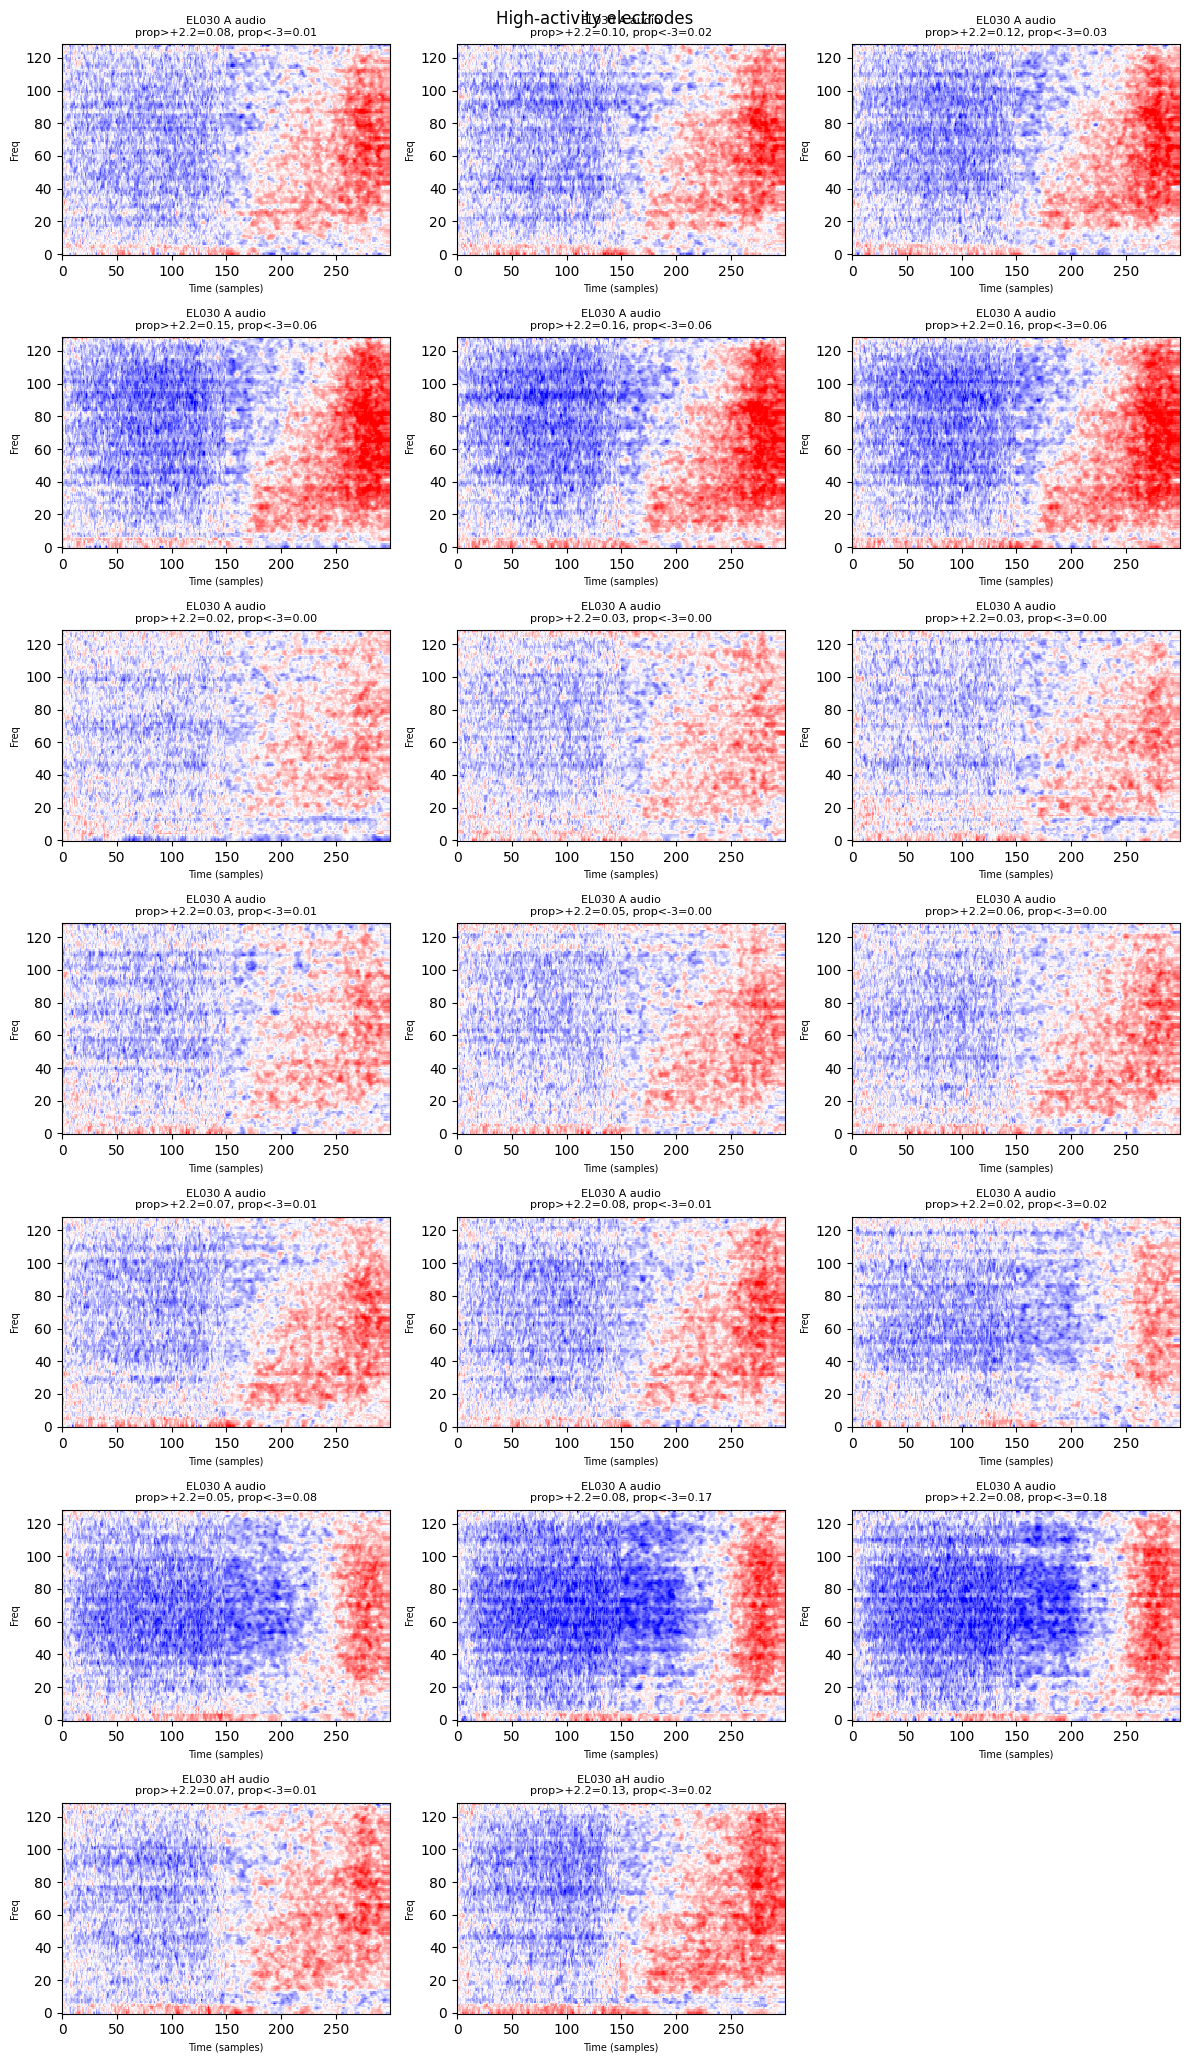

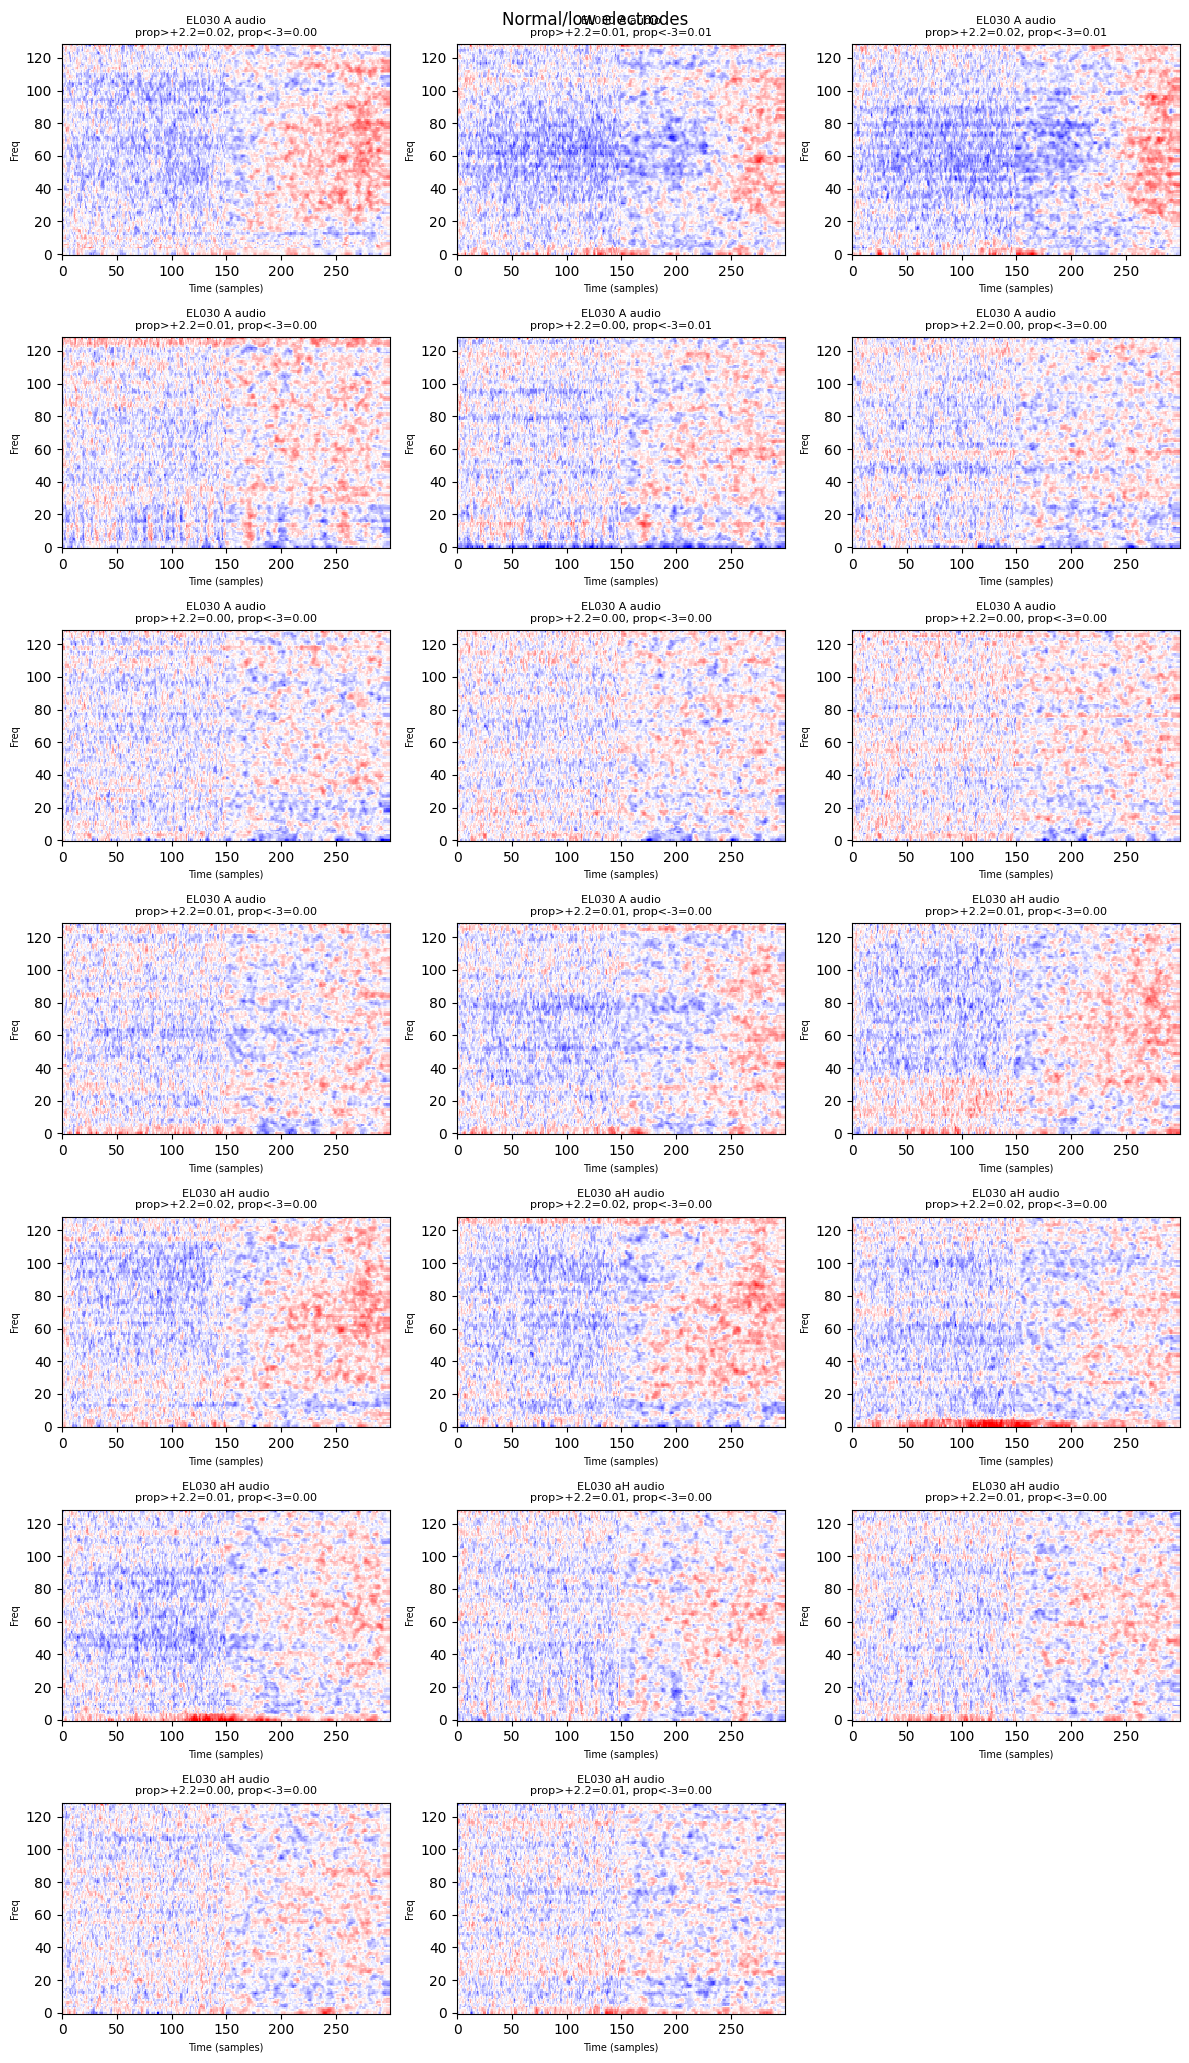

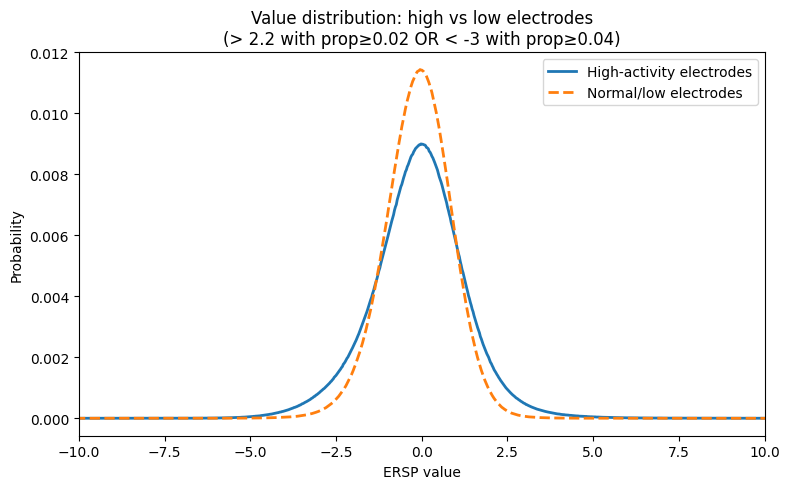

In [26]:
## 4.x High-activity electrode screening & visualization (pos + neg thresholds)

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
thr_pos = 2.2        # positive threshold
min_prop_pos = 0.02  # min proportion (> thr_pos) to be considered high-positive

thr_neg = -3       # negative threshold
min_prop_neg = 0.04  # min proportion (< thr_neg) to be considered high-negative

max_examples = 20    # how many electrodes to plot from each group
n_bins = 1000        # histogram bins for value distributions

if len(ersp_list) == 0:
    raise RuntimeError("No ERSP data available after exclusions.")

# --- 1) Compute proportions above/below thresholds per electrode ---
prop_pos = []
prop_neg = []
high_flags = []

for arr in ersp_list:
    vals = arr  # shape (N_FREQ, N_TIME)

    mask_pos = vals > thr_pos
    mask_neg = vals < thr_neg

    p_pos = mask_pos.mean()
    p_neg = mask_neg.mean()

    prop_pos.append(p_pos)
    prop_neg.append(p_neg)

    high_flags.append((p_pos >= min_prop_pos) or (p_neg >= min_prop_neg))

df_meta["prop_above_pos"] = prop_pos
df_meta["prop_below_neg"] = prop_neg
df_meta["high_activity"] = high_flags

n_high = df_meta["high_activity"].sum()
n_low  = len(df_meta) - n_high

print(f"Positive threshold: value > {thr_pos}, high if prop ≥ {min_prop_pos:.2f}")
print(f"Negative threshold: value < {thr_neg}, high if prop ≥ {min_prop_neg:.2f}")
print(f"High-activity electrodes: {n_high}")
print(f"Normal/low electrodes:    {n_low}")

# --- 2) Visualize a few ERSPs from each group (high vs low) ---

high_idx = df_meta.index[df_meta["high_activity"]].tolist()
low_idx  = df_meta.index[~df_meta["high_activity"]].tolist()

print("\nExample high-activity electrodes:")
display(
    df_meta.loc[high_idx, ["patient_id", "electrode", "condition",
                           "prop_above_pos", "prop_below_neg"]]
    .sort_values(["prop_above_pos", "prop_below_neg"], ascending=[False, False])
    .head(min(max_examples, len(high_idx)))
)

print("\nExample normal/low electrodes:")
display(
    df_meta.loc[low_idx, ["patient_id", "electrode", "condition",
                          "prop_above_pos", "prop_below_neg"]]
    .sort_values(["prop_above_pos", "prop_below_neg"], ascending=[True, True])
    .head(min(max_examples, len(low_idx)))
)

# Determine common color scale from subset for visualization
all_vals_sample = []
for i in (high_idx[:max_examples] + low_idx[:max_examples]):
    all_vals_sample.append(ersp_list[i].ravel())
if all_vals_sample:
    all_vals_sample = np.concatenate(all_vals_sample)
    v = np.nanmax(np.abs(all_vals_sample))
    vmin, vmax = -v, v
else:
    vmin = vmax = None

def plot_group_examples(indices, title_prefix):
    n = min(max_examples, len(indices))
    if n == 0:
        print(f"No electrodes in group '{title_prefix}', skipping plots.")
        return

    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, indices[:n]):
        ersp = ersp_list[idx]
        meta = df_meta.iloc[idx]

        im = ax.imshow(
            ersp,
            aspect="auto",
            origin="lower",
            cmap="bwr",
            vmin=-5,
            vmax=5,
            interpolation="nearest",
        )
        ax.set_title(
            f"{meta['patient_id']} {meta['electrode']} {meta['condition']}\n"
            f"prop>+{thr_pos}={meta['prop_above_pos']:.2f}, "
            f"prop<{thr_neg}={meta['prop_below_neg']:.2f}",
            fontsize=8,
        )
        ax.set_xlabel("Time (samples)", fontsize=7)
        ax.set_ylabel("Freq", fontsize=7)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(f"{title_prefix} electrodes", fontsize=12)
    plt.tight_layout()
    plt.show()

# Plot examples
plot_group_examples(high_idx, "High-activity")
plot_group_examples(low_idx,  "Normal/low")

# --- 3) Compare value distributions (high vs low) without giant arrays ---

glob_min, glob_max = np.inf, -np.inf
for arr in ersp_list:
    m = np.nanmin(arr)
    M = np.nanmax(arr)
    if m < glob_min:
        glob_min = m
    if M > glob_max:
        glob_max = M

bins = np.linspace(glob_min, glob_max, n_bins + 1)
high_hist = np.zeros(n_bins, dtype=np.float64)
low_hist  = np.zeros(n_bins, dtype=np.float64)

for idx, arr in enumerate(ersp_list):
    vals = arr.ravel()
    h, _ = np.histogram(vals, bins=bins)
    if df_meta.iloc[idx]["high_activity"]:
        high_hist += h
    else:
        low_hist += h

high_hist = high_hist / high_hist.sum() if high_hist.sum() > 0 else high_hist
low_hist  = low_hist  / low_hist.sum()  if low_hist.sum()  > 0 else low_hist

bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, high_hist, label="High-activity electrodes", linewidth=2)
plt.plot(bin_centers, low_hist,  label="Normal/low electrodes", linewidth=2, linestyle="--")
plt.xlabel("ERSP value")
plt.ylabel("Probability")
plt.xlim((-10, 10))
plt.title(
    "Value distribution: high vs low electrodes\n"
    f"(> {thr_pos} with prop≥{min_prop_pos:.2f} OR "
    f"< {thr_neg} with prop≥{min_prop_neg:.2f})"
)
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
## 4.y Filter out low-activity electrodes (keep only high-activity)

if "high_activity" not in df_meta.columns:
    raise RuntimeError("Column 'high_activity' not found. Run the threshold cell first.")

# Determine indices to keep
keep_idx = df_meta.index[df_meta["high_activity"]].tolist()
drop_idx = df_meta.index[~df_meta["high_activity"]].tolist()

print("====== High-Activity Electrode Filtering ======")
print(f"Total electrodes before filtering: {len(df_meta)}")
print(f"High-activity electrodes kept:    {len(keep_idx)}")
print(f"Low-activity electrodes removed:   {len(drop_idx)}")
print("===============================================")



# Apply filtering to df_meta and ersp_list
df_meta = df_meta.loc[keep_idx].reset_index(drop=True)
ersp_list = [ersp_list[i] for i in keep_idx]

print("\nAfter filtering:")
print("  df_meta rows:", len(df_meta))
print("  ersp_list len:", len(ersp_list))

# Optional: rebuild sample_idx if you use it later
df_meta["sample_idx"] = np.arange(len(df_meta))


====== High-Activity Electrode Filtering ======
Total electrodes before filtering: 7268
High-activity electrodes kept:    1538
Low-activity electrodes removed:   5730

After filtering:
  df_meta rows: 1538
  ersp_list len: 1538


In [28]:
# ## 3.2. UMAP embedding: inspect all samples 
# #                      to decide which ones to remove

# import numpy as np
# import matplotlib.pyplot as plt
# import umap
# from sklearn.utils import validation as skl_validation

# # --- Safety checks ---
# if len(ersp_list) == 0:
#     raise RuntimeError("No ERSP data loaded, cannot run UMAP.")

# # Make sure UMAP uses the modern sklearn check_array (fix for ensure_all_finite issue)
# umap.umap_.check_array = skl_validation.check_array

# # --- In-place NaN fix on ERSPs (freq x time) ---
# for arr in ersp_list:
#     np.nan_to_num(arr, nan=0.0, copy=False)

# # --- Build feature matrix directly: (n_samples, N_FREQ * N_TIME) as float32 ---
# n_samples = len(ersp_list)
# X_raw = np.empty((n_samples, N_FREQ * N_TIME), dtype=np.float32)

# for i, arr in enumerate(ersp_list):
#     # arr shape: (N_FREQ, N_TIME) = (129, 300)
#     X_raw[i, :] = arr.reshape(-1)

# print("X_raw shape for UMAP:", X_raw.shape)

# # --- Run UMAP on raw (flattened) data ---
# umap_model = umap.UMAP(
#     n_neighbors=15,
#     min_dist=0.1,
#     n_components=2,
#     metric="euclidean",
#     random_state=42,
# )

# embedding = umap_model.fit_transform(X_raw)
# print("UMAP embedding shape:", embedding.shape)

# # Attach embedding directly to df_meta (no extra copy)
# df_meta["UMAP_1"] = embedding[:, 0]
# df_meta["UMAP_2"] = embedding[:, 1]

# # --------------------------------------------------------------------
# # Plot 1: UMAP colored by patient, with electrode labels
# # --------------------------------------------------------------------
# fig, ax = plt.subplots(figsize=(10*2, 10*2))  # ~4x bigger area than 6x5

# patient_codes, patient_uniques = pd.factorize(df_meta["patient_id"])
# sc = ax.scatter(
#     df_meta["UMAP_1"],
#     df_meta["UMAP_2"],
#     c=patient_codes,
#     s=15,
#     alpha=0.7,
# )

# ax.set_title("UMAP – colored by patient_id", fontsize=14)
# ax.set_xlabel("UMAP 1", fontsize=12)
# ax.set_ylabel("UMAP 2", fontsize=12)

# # Add electrode name as text next to each point
# for x, y, label in zip(df_meta["UMAP_1"], df_meta["UMAP_2"], df_meta["electrode"]):
#     ax.text(x, y, str(label), fontsize=5, alpha=0.7)

# # Legend for patients
# handles = []
# labels = []
# cmap = sc.cmap
# norm = plt.Normalize(vmin=patient_codes.min(), vmax=patient_codes.max())

# for code, pid in enumerate(patient_uniques):
#     handles.append(
#         plt.Line2D(
#             [], [], marker="o", linestyle="", markersize=6,
#             color=cmap(norm(code))
#         )
#     )
#     labels.append(pid)

# ax.legend(handles, labels, title="patient_id", fontsize=8, loc="best")
# plt.tight_layout()
# plt.show()



In [29]:
## 4. Build X_raw (flattened) and standardize

if len(ersp_list) == 0:
    raise RuntimeError("No ERSP data loaded. Check paths and file patterns.")

# Stack into (n_samples, N_TIME, N_FREQ)
X_3d = np.stack(ersp_list, axis=0)  # shape: (n_samples, 300, 128)
print("X_3d shape:", X_3d.shape)

# Flatten each matrix into a single vector (row-major)
X_raw = X_3d.reshape(X_3d.shape[0], -1)  # shape: (n_samples, 38400)
print("X_raw shape:", X_raw.shape)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print("X_scaled shape:", X_scaled.shape)

# Quick sanity check on a subset of features
print("Mean (first 10 features):", X_scaled[:,:10].mean(axis=0))
print("Std  (first 10 features):", X_scaled[:, :10].std(axis=0))


X_3d shape: (1538, 129, 300)
X_raw shape: (1538, 38700)
X_scaled shape: (1538, 38700)
Mean (first 10 features): [-7.55067155e-17 -1.74460396e-16  2.02770902e-16 -1.65234103e-16
  1.42351093e-16 -6.38125588e-17 -6.38847449e-18  1.84778504e-16
  2.22549908e-16  1.50724686e-16]
Std  (first 10 features): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Clustering

Two methods on the same `X_scaled`: K-Means (with K sweep) and Hierarchical (Ward).
Each `fit_and_save` call writes a self-contained run directory and updates `outputs/clustering/index.json`.


In [30]:
from functions import lf_cluster_run as R

# Sweep K to let silhouette pick the best, but cap to a reasonable range
K_RANGE = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

manifest_km = R.fit_and_save(
    X_scaled,
    df_keep=df_meta,
    method='kmeans',
    feature_set='raw',
    params={'k_range': K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    scaler=scaler,
    method_label='K-Means',
    feature_set_label='Raw ERSP',
    notebook=SCRIPT_NAME,
)
BEST_K = manifest_km['summary']['best_k']
print(f"Best K (KMeans, by silhouette): {BEST_K}")


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  K= 10  sil=0.0414


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  K= 11  sil=0.0460


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


...

  K= 19  sil=0.0585


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  K= 20  sil=0.0583

[KMeans] Best K=19  silhouette=0.0585


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[fit_and_save] kmeans/raw/20260521_151047
  n_samples=1538 n_clusters=19 silhouette=0.059
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\kmeans\raw\runs\20260521_151047
Best K (KMeans, by silhouette): 19


In [31]:
# Hierarchical (Ward) — K-sweep so MOBA can scrub. linkage_Z is saved once and
# every K cut goes into cluster_labels_by_k.csv. Best K (by silhouette) is the
# default cut in labels.csv.
manifest_hc = R.fit_and_save(
    X_scaled,
    df_keep=df_meta,
    method='hierarchical',
    feature_set='raw',
    params={'linkage': 'ward', 'metric': 'euclidean', 'k_range': K_RANGE},
    scaler=scaler,
    method_label='Hierarchical (Ward)',
    feature_set_label='Raw ERSP',
    notebook=SCRIPT_NAME,
)
print(f'Best K (HC/raw, by silhouette): {manifest_hc["summary"]["best_k"]}')


[HC] method=ward  metric=euclidean  n=1538  cophenetic_r=0.617


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  HC sweep k=10: silhouette=0.034


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  HC sweep k=11: silhouette=0.039


...

  HC sweep k=19: silhouette=0.049


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  HC sweep k=20: silhouette=0.052


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[fit_and_save] hierarchical/raw/20260521_151543
  n_samples=1538 n_clusters=20 silhouette=0.052
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hierarchical\raw\runs\20260521_151543
Best K (HC/raw, by silhouette): 20


## ERSP-shaped centroid grids

The orchestrator's `centroids.png` is a generic cluster × feature heatmap. For raw ERSP,
the features have a natural (N_FREQ, N_TIME) shape, so we render a method-specific grid below
for both runs.


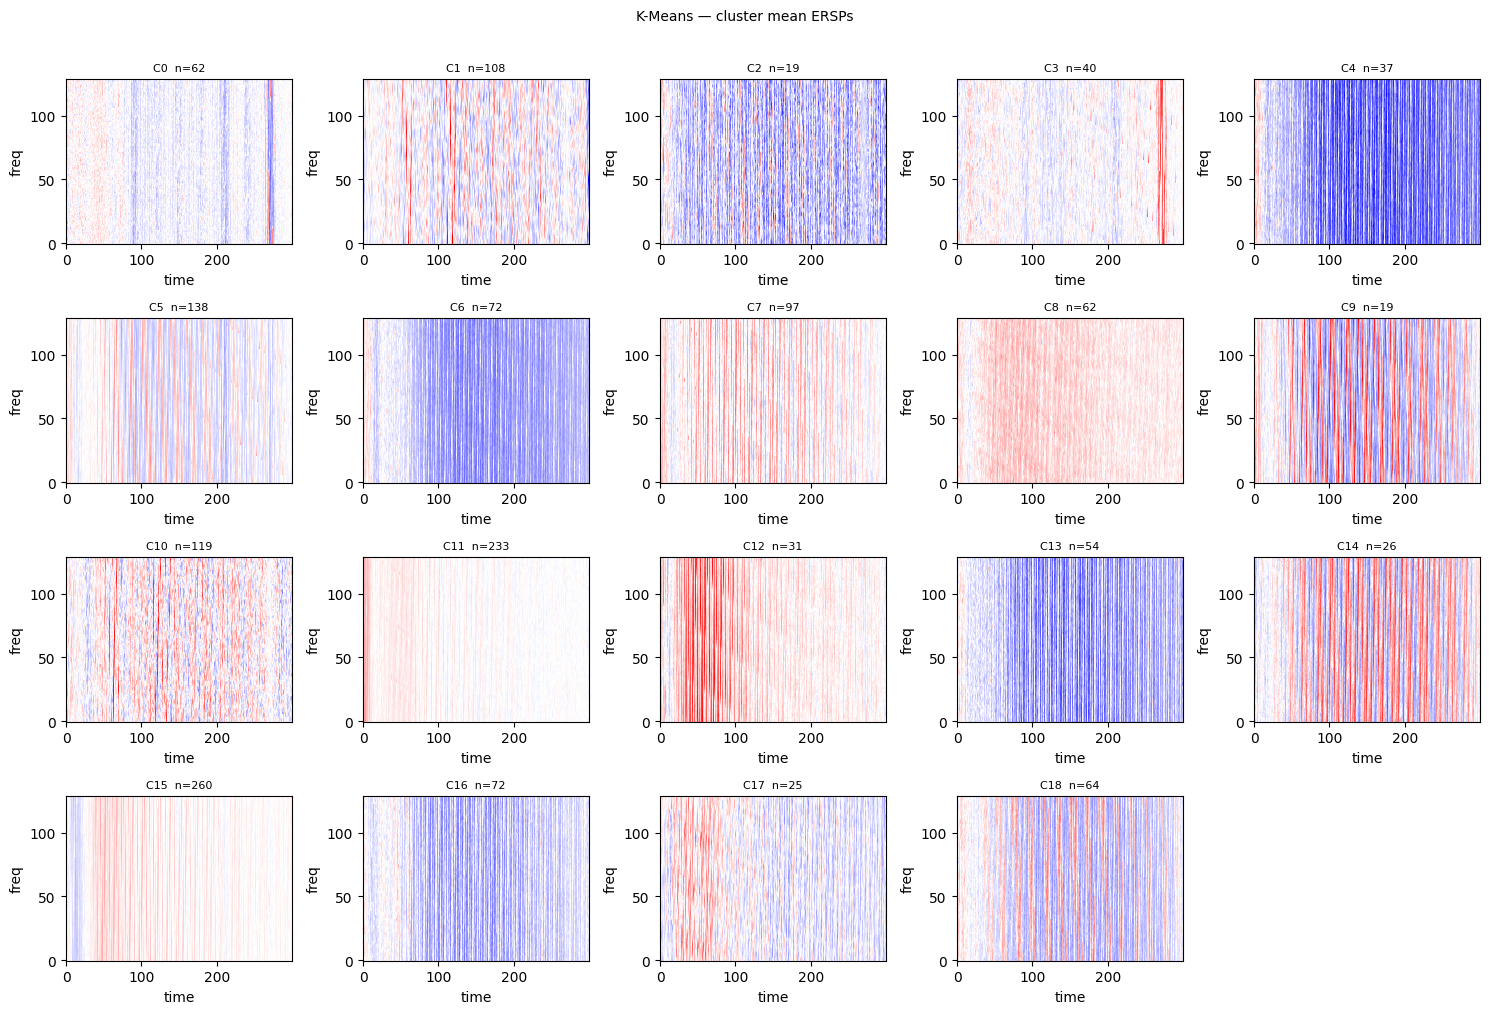

[saved] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\kmeans\raw\runs\20260521_151047\cluster_mean_ersps.png


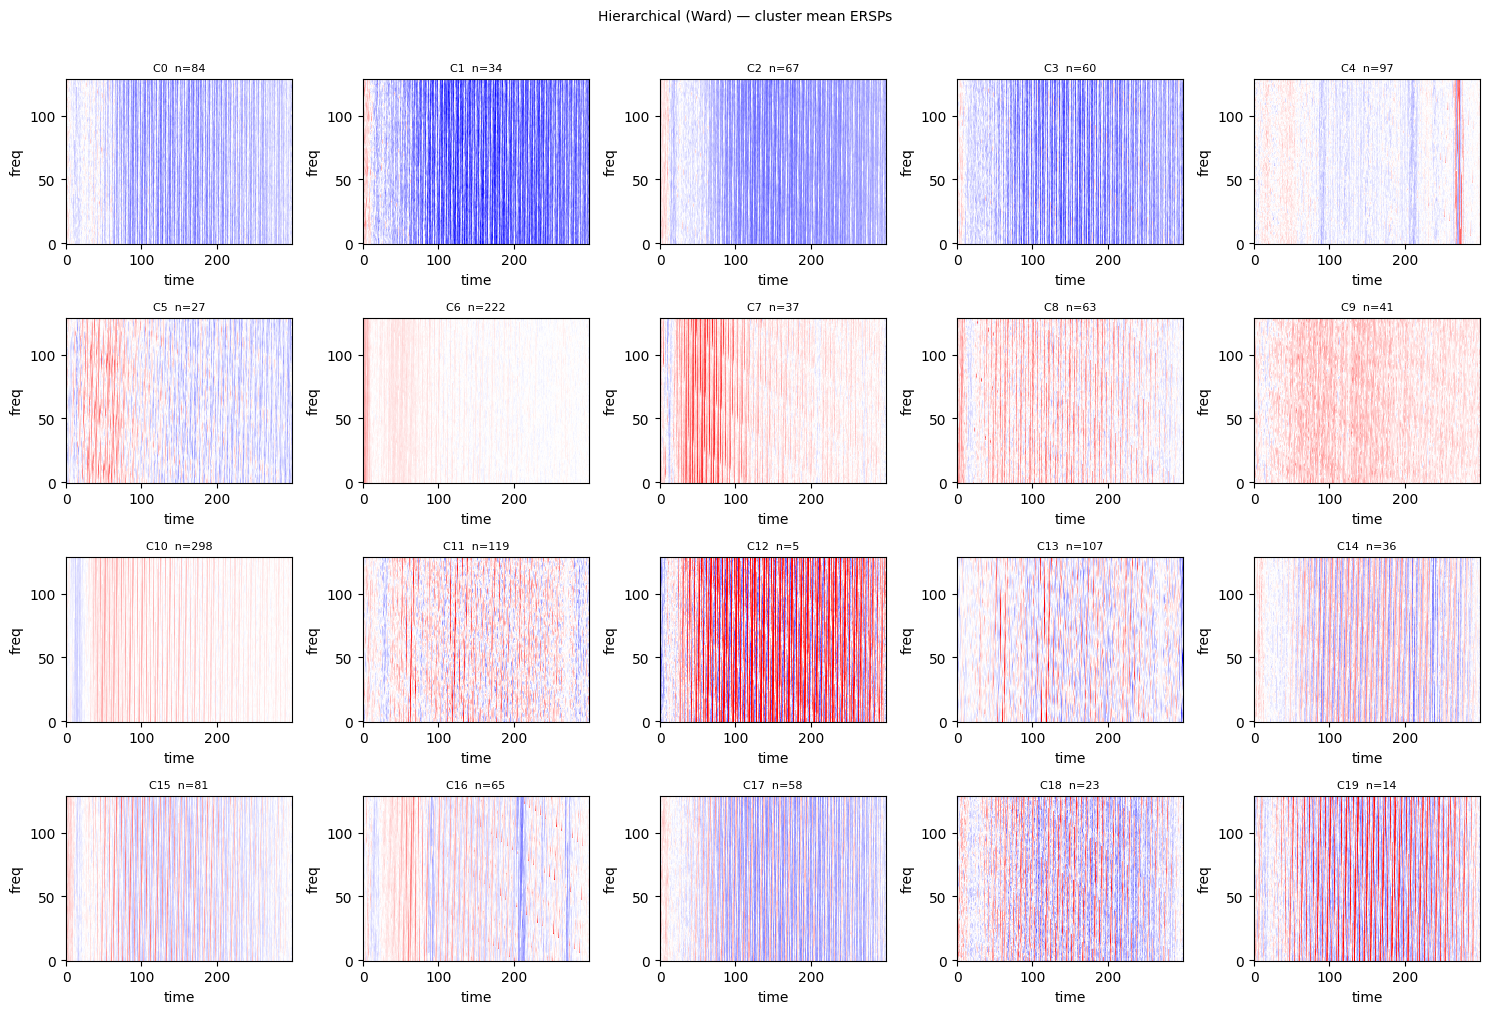

[saved] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hierarchical\raw\runs\20260521_151543\cluster_mean_ersps.png


In [32]:
# TODO: NEeds to be transformed 

from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def _ersp_centroid_grid(manifest, X_3d, *, n_cols=5, vlim=5.0):
    """Reload labels for a saved run, compute per-cluster mean ERSP, plot grid."""
    run_dir = Path('\\\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\\02_FBM_Clustering\\outputs\\clustering') / manifest['method'] \
        / manifest['feature_set'] / 'runs' / manifest['run_id']
    labels = pd.read_csv(run_dir / 'labels.csv')['cluster_'+manifest['method']+'_'+manifest['feature_set']].to_numpy()
    uniq = np.unique(labels)
    k = len(uniq)
    n_rows = int(np.ceil(k / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.5*n_rows))
    axes = np.atleast_1d(axes).reshape(-1)
    for i, c in enumerate(uniq):
        idx = np.where(labels == c)[0]
        mean_ersp = X_3d[idx].mean(axis=0).reshape(N_TIME, N_FREQ)
        ax = axes[i]
        ax.imshow(mean_ersp.T, aspect='auto', origin='lower',
                  cmap='bwr', vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax.set_title(f'C{c}  n={len(idx)}', fontsize=8)
        ax.set_xlabel('time'); ax.set_ylabel('freq')
    for ax in axes[k:]:
        ax.axis('off')
    plt.suptitle(f"{manifest['method_label']} — cluster mean ERSPs", y=1.01, fontsize=10)
    plt.tight_layout()
    out_path = run_dir / 'cluster_mean_ersps.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[saved] {out_path}')

_ersp_centroid_grid(manifest_km, X_3d)
_ersp_centroid_grid(manifest_hc, X_3d)


## Inspect cluster cohesion + separation

The orchestrator already saved these figures into each run dir; display them inline for quick comparison.
- **silhouette_per_cluster.png** — which clusters are tight; which are catch-alls.
- **similarity_heatmap.png** — pairwise distance reordered by cluster; tight block-diagonal = good.
- **centroid_distance_heatmap.png** — inter-cluster separation.


In [33]:
# from IPython.display import Image, display, Markdown
# from pathlib import Path

# def _show_run_figures(manifest):
#     run_dir = Path('02_FBM_Clustering/outputs/clustering') / manifest['method'] \
#         / manifest['feature_set'] / 'runs' / manifest['run_id']
#     display(Markdown(f"### {manifest['method_label']} · {manifest['feature_set_label']} · run {manifest['run_id']}"))
#     s = manifest['summary']
#     display(Markdown(
#         f"- n_samples = **{s['n_samples']}**, n_clusters = **{s['n_clusters']}**\n"
#         f"- silhouette = **{s['silhouette_overall']:.3f}**, "
#         f"calinski_harabasz = **{s['calinski_harabasz']:.1f}**, "
#         f"davies_bouldin = **{s['davies_bouldin']:.3f}**\n"
#     ))
#     for name in ['silhouette_per_cluster.png', 'similarity_heatmap.png',
#                  'centroid_distance_heatmap.png']:
#         p = run_dir / name
#         if p.exists():
#             display(Image(filename=str(p)))

# _show_run_figures(manifest_km)
# _show_run_figures(manifest_hc)


## Per-cluster centroid PNGs (for the MOBA cluster chips)

Re-runs cheap: no fitting, just `mean(X_3d[labels==c]).reshape(...)` and
`imshow` per cluster. Iterates every run in `index.json` and writes
`<run_dir>/cluster_centroids/cluster_<NN>.png` (one per cluster) so the
MOBA cluster filter chips can show a tiny mean-ERSP thumbnail per cluster.
Skips any run whose `feature_set` isn't `raw` (the others have a different
feature shape that doesn't make sense to display as an ERSP).


In [37]:
# BACKFILL_CENTROIDS — per-cluster mean-ERSP thumbnails for the MOBA chips.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CLUSTERING_DIR = Path('\\\\nasac-m2.unige.ch\\m-HumanNeuronLab\\ANALYSIS\\FLM\\Analysis_LoraFanda\\02_FBM_Clustering\\outputs\\clustering')
INDEX_PATH = CLUSTERING_DIR / 'index.json'


def _save_per_cluster_centroid_pngs(manifest, X_3d_local, *, vlim=5.0):
    """For one run, write `<run_dir>/cluster_centroids/cluster_<NN>.png`."""
    if manifest['feature_set'] != 'raw':
        return 0
    run_dir = CLUSTERING_DIR / manifest['method'] / manifest['feature_set'] \
        / 'runs' / manifest['run_id']
    cluster_col = f"cluster_{manifest['method']}_{manifest['feature_set']}"
    df = pd.read_csv(run_dir / 'labels.csv')
    if cluster_col not in df.columns:
        # Fall back to whichever cluster_* column exists
        cands = [c for c in df.columns if c.startswith('cluster_')]
        if not cands: return 0
        cluster_col = cands[0]

    labels = df[cluster_col].to_numpy()
    if len(labels) != X_3d_local.shape[0]:
        print(f"  [skip] {manifest['run_id']}: labels ({len(labels)}) vs X_3d "
              f"({X_3d_local.shape[0]}) length mismatch — re-run 210 data load "
              f"with the same patient set as this run")
        return 0

    out_dir = run_dir / 'cluster_centroids'
    out_dir.mkdir(parents=True, exist_ok=True)

    uniq = sorted(int(c) for c in np.unique(labels))
    for c in uniq:
        idx = np.where(labels == c)[0]
        mean_ersp = X_3d_local[idx].mean(axis=0).reshape(N_TIME, N_FREQ)
        fig, ax = plt.subplots(figsize=(2, 1.5))
        ax.imshow(mean_ersp.T, aspect='auto', origin='lower',
                  cmap='bwr', vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        out_path = out_dir / f'cluster_{int(c):02d}.png'
        fig.savefig(out_path, dpi=80, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    return len(uniq)


# Iterate every run in the index and backfill
if not INDEX_PATH.exists():
    print(f'No {INDEX_PATH} yet — run 210 cell 11/12 first.')
else:
    with open(INDEX_PATH) as f:
        idx = json.load(f)
    runs = idx.get('runs', [])
    print(f'Backfilling per-cluster centroid PNGs for {len(runs)} runs...')
    for run in runs:
        run_dir = CLUSTERING_DIR / run['path']
        manifest_path = run_dir / 'manifest.json'
        if not manifest_path.exists():
            print(f"  [skip] {run['path']}: missing manifest.json"); continue
        with open(manifest_path) as f:
            manifest = json.load(f)
        n = _save_per_cluster_centroid_pngs(manifest, X_3d)
        if n:
            print(f"  [{manifest['method']}/{manifest['feature_set']}] "
                  f"{manifest['run_id']}  ->  {n} cluster PNGs")
    print('\nDone. Commit and push:')
    print('  git add 02_FBM_Clustering/outputs/clustering')
    print('  git commit -m "Per-cluster centroid PNGs for MOBA chips"')
    print('  git push')


Backfilling per-cluster centroid PNGs for 10 runs...
  [skip] 20260514_021645: labels (1652) vs X_3d (1538) length mismatch — re-run 210 data load with the same patient set as this run
  [hierarchical/raw] 20260519_121535  ->  20 cluster PNGs
  [hierarchical/raw] 20260521_151543  ->  20 cluster PNGs
  [skip] 20260514_021021: labels (1652) vs X_3d (1538) length mismatch — re-run 210 data load with the same patient set as this run
  [kmeans/raw] 20260519_121019  ->  19 cluster PNGs
  [kmeans/raw] 20260521_151047  ->  19 cluster PNGs

Done. Commit and push:
  git add 02_FBM_Clustering/outputs/clustering
  git commit -m "Per-cluster centroid PNGs for MOBA chips"
  git push
